In [8]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [9]:
%run data_preparation.py

/home/pawluk/nova/ml/assignment-1/NOVA_ML_Project1/data_preparation.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = pd.read_csv(_path)


Function from Task 2

In [10]:
def validate_poly_regression(
    X_train,
    y_train,
    X_val,
    y_val,
    regressor=None,
    degrees=range(1, 15),
    max_features=None,
):
    if regressor is None:
        # No regularization
        regressor = LinearRegression()

    best_rmse = np.inf
    best_model = None
    num_input_features = X_train.shape[1]

    for d in degrees:
        expected_num_poly_features = comb(num_input_features + d, d)

        # Check if we exceed max_features limit
        if max_features is not None and expected_num_poly_features > max_features:
            # print(f"degree={d:2d} -> poly features: {expected_num_poly_features:,} | SKIPPED (exceeds max_features={max_features:,})")
            continue


        model = make_pipeline(
            PolynomialFeatures(degree=d),
            StandardScaler(),
            clone(regressor)
        )


        model.fit(X_train, y_train)

        num_poly_features = model[0].n_output_features_
        y_pred = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))

        # OUTPUT COMMENTS
        # print(f"degree ={d:2d} ->\n\tnumber of polynomial features: {num_poly_features:,} (expected: {expected_num_poly_features:,}) | RMSE={rmse:.6f}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model
            best_degree = d


    return best_model, best_rmse, best_degree

## TASK 3.1 Exploratory Analysis (pairplot + correlation matrix)

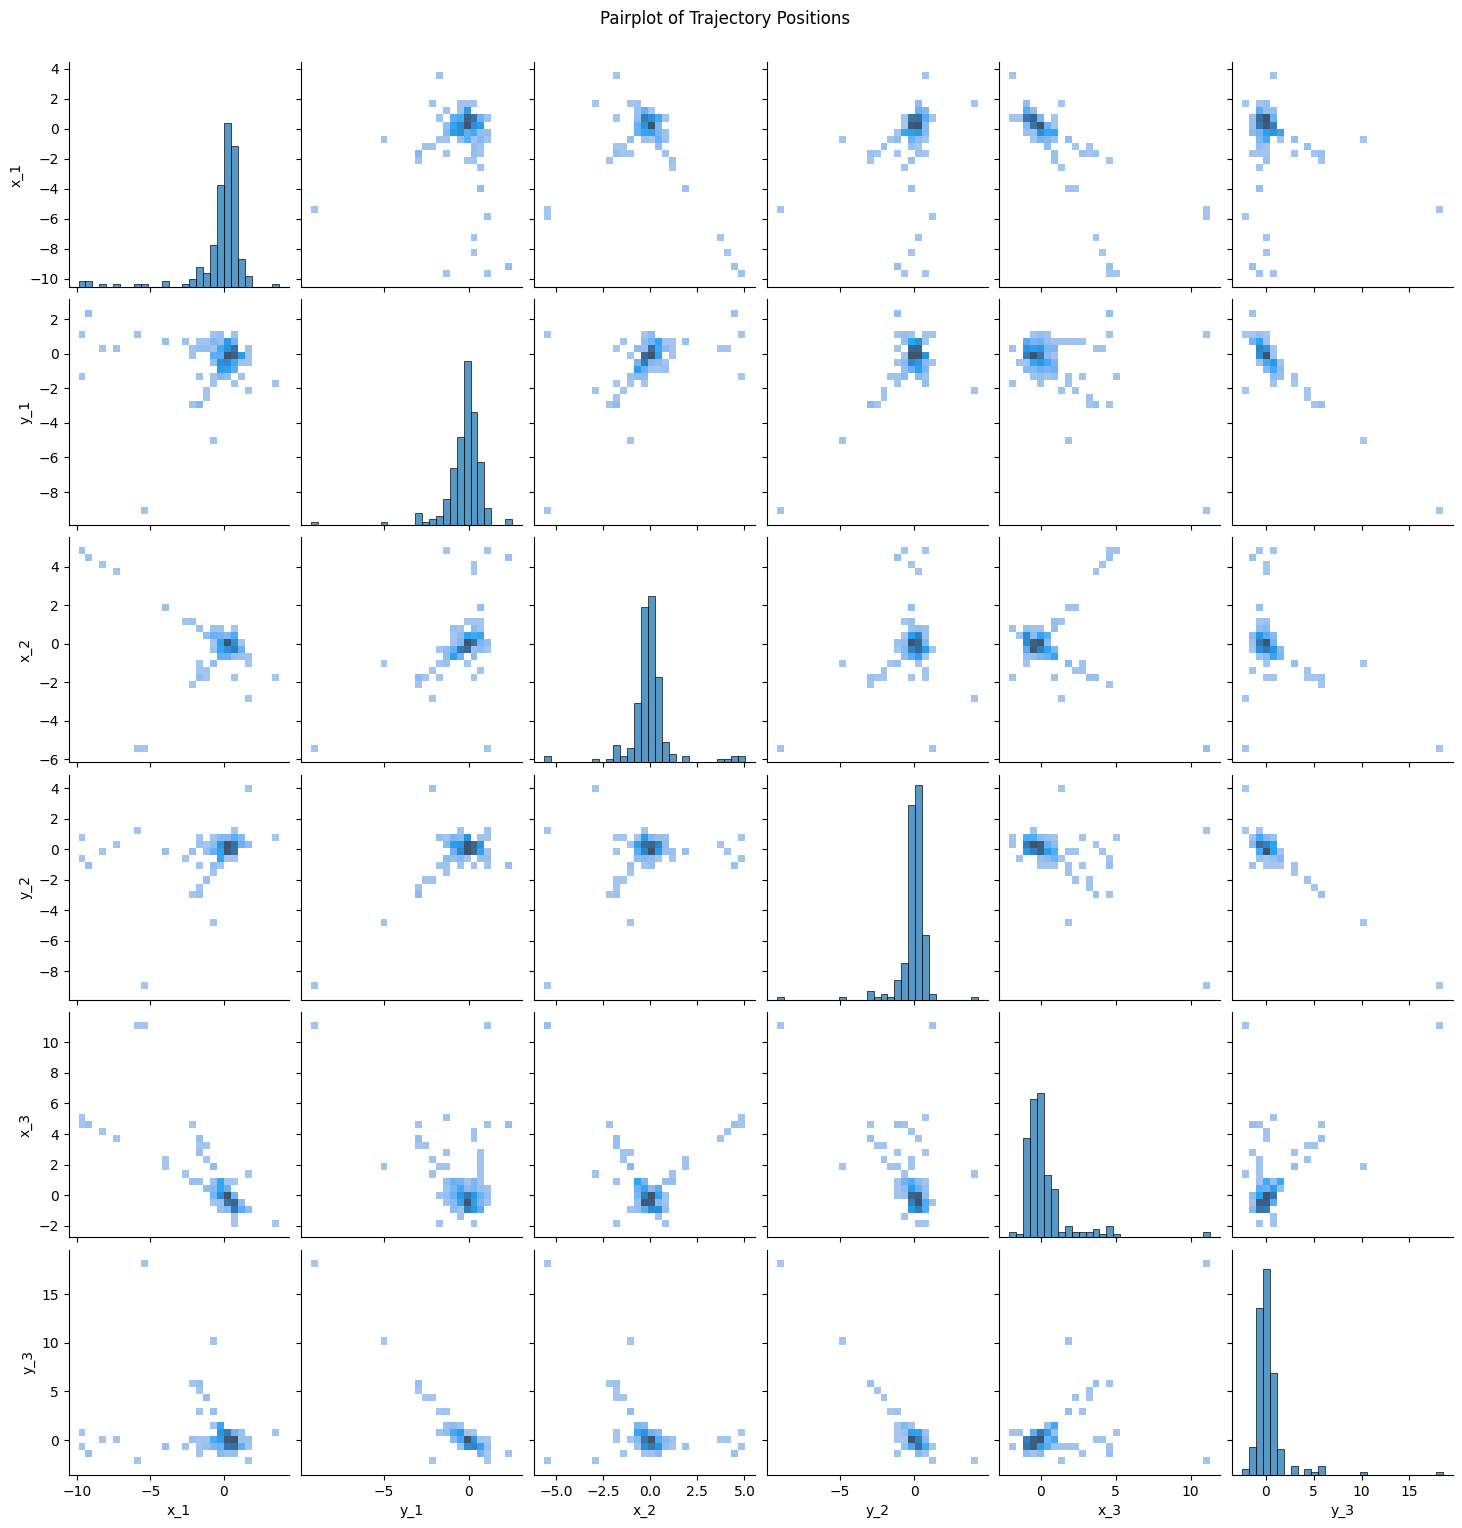

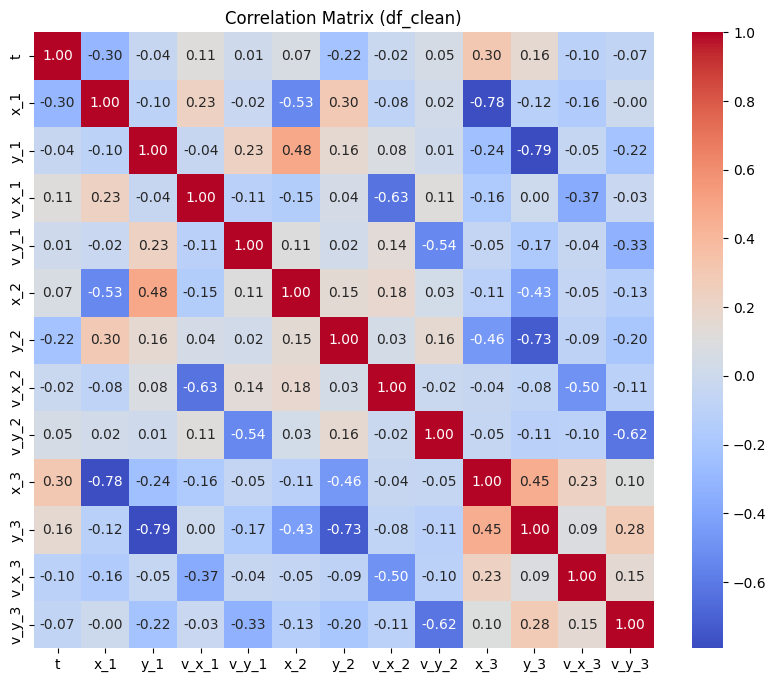

In [11]:
from data_preparation import df_clean
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot of sample trajectories
sns.pairplot(
    df_clean.sample(200, random_state=42),
    vars=["x_1", "y_1", "x_2", "y_2", "x_3", "y_3"],
    kind="hist"
)
plt.suptitle("Pairplot of Trajectory Positions", y=1.02)
plt.show()

# Correlation matrix for numeric features
corr = (
    df_clean.select_dtypes(include=["number"])
    .drop(columns=["Id", "traj_id", "zero_tail"], errors="ignore")
    .corr()
)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (df_clean)")
plt.show()


## TASK 3.2 Feature correlation analysis and baseline linear model

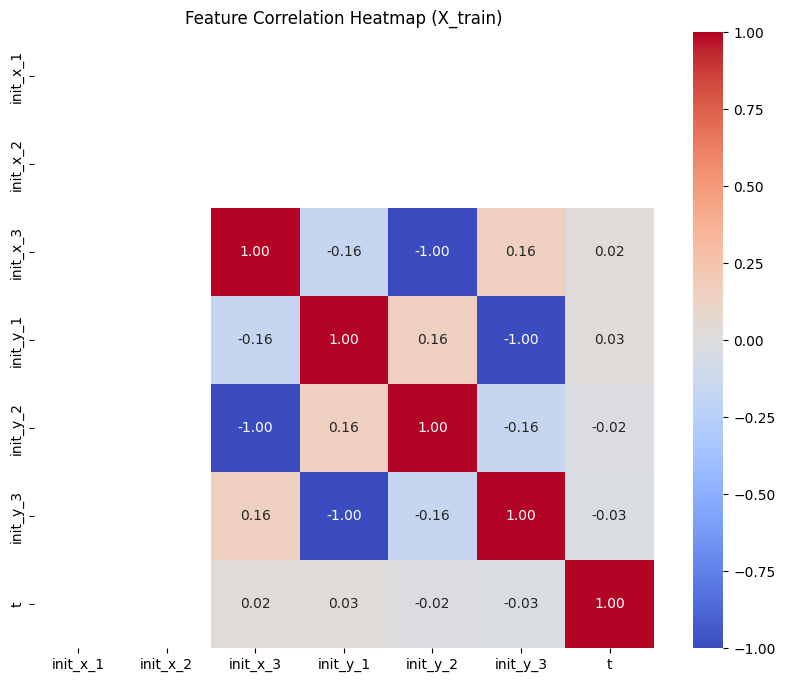

Top 5 most correlated feature pairs:
 init_x_3  init_y_1    0.159195
init_y_2  init_y_3    0.159195
          init_y_1    0.159195
t         init_y_1    0.027270
          init_y_2    0.017257
dtype: float64

--- Feature Removal Experiment ---
Baseline: RMSE = 1.40063
Removed init_x_3: RMSE = 1.40063
ΔRMSE = -0.00000

Removed init_y_2: RMSE = 1.40063
ΔRMSE = +0.00000

Removed init_y_2: RMSE = 1.40063
ΔRMSE = +0.00000

Removed t: RMSE = 1.40272
ΔRMSE = +0.00210

Removed t: RMSE = 1.40272
ΔRMSE = +0.00210



In [12]:
from data_preparation import X_train, y_train, X_val, y_val
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

feature_names = [f"init_x_{i}" for i in range(1, 4)] + [f"init_y_{i}" for i in range(1, 4)] + ["t"]
X_train_df = pd.DataFrame(X_train, columns=feature_names)

# Correlation heatmap
corr = X_train_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap (X_train)")
plt.show()

# Top 5 most correlated feature pairs
corr_pairs = corr.abs().unstack().sort_values(ascending=False).drop_duplicates()
corr_pairs = corr_pairs[corr_pairs < 0.9999]
top_corr = corr_pairs.head(5)
print("Top 5 most correlated feature pairs:\n", top_corr)

features_to_remove = [f1 for (f1, f2) in top_corr.index]

def evaluate_model(X_train_sub, X_val_sub, label):
    model = make_pipeline(StandardScaler(), LinearRegression())
    model.fit(X_train_sub, y_train)
    y_pred = model.predict(X_val_sub)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    print(f"{label}: RMSE = {rmse:.5f}")
    return rmse

print("\n--- Feature Removal Experiment ---")
rmse_baseline = evaluate_model(X_train, X_val, "Baseline")

for feat in features_to_remove:
    if feat not in X_train_df.columns:
        continue
    idx = X_train_df.columns.get_loc(feat)
    X_train_reduced = np.delete(X_train, idx, axis=1)
    X_val_reduced = np.delete(X_val, idx, axis=1)
    rmse_reduced = evaluate_model(X_train_reduced, X_val_reduced, f"Removed {feat}")
    print(f"ΔRMSE = {rmse_reduced - rmse_baseline:+.5f}\n")


## Feature reduction and polynomial regression validation

Top 3 most correlated feature pairs:
 init_x_3  init_y_1    0.159195
init_y_3  init_x_3    0.159195
init_x_3  init_y_3    0.159195
init_y_1  init_x_3    0.159195
dtype: float64

Features to remove (unique): ['init_x_3', 'init_y_3', 'init_y_1']

Original feature count: 7 → Reduced: 4

Baseline RMSE: 1.40063 (deg=1)
Reduced  RMSE: 1.42688 (deg=3)
ΔRMSE = +0.02626


/home/pawluk/nova/ml/assignment-1/NOVA_ML_Project1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


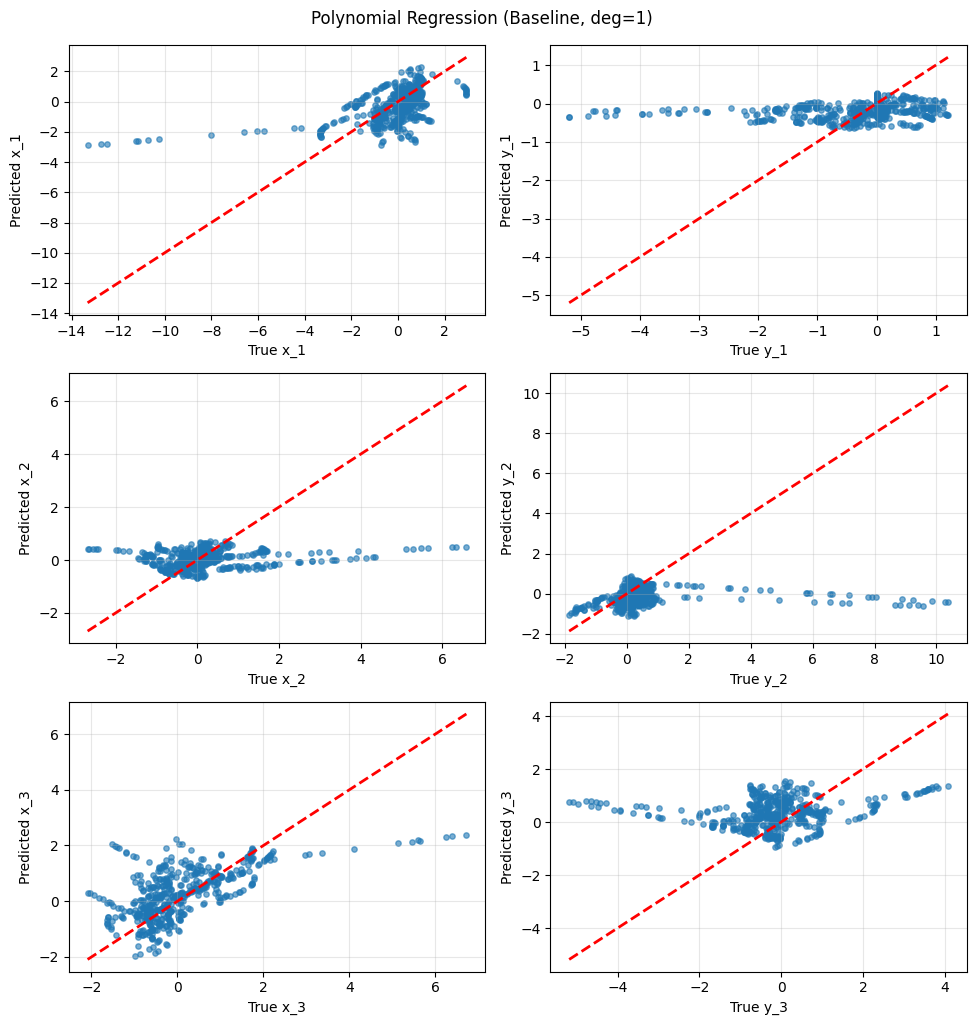

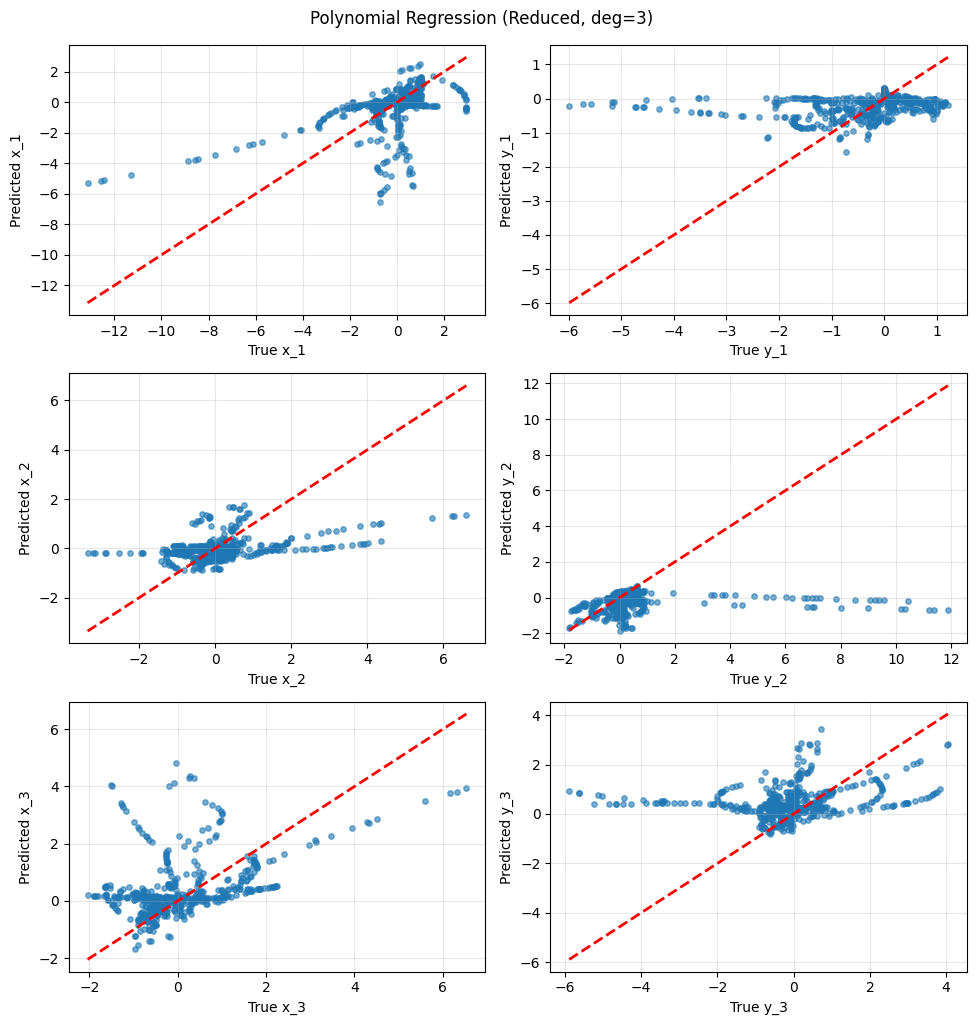


Summary:
Baseline RMSE: 1.40063
Reduced RMSE: 1.42688
→ Slight RMSE difference — minor information loss possible.


/home/pawluk/nova/ml/assignment-1/NOVA_ML_Project1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(



Saved submission to: results/reduced_polynomial_submission.csv


In [13]:
from data_preparation import RESULTS_DIR, X_test, X_train, X_val, y_train, y_val
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

feature_names = [f"init_x_{i}" for i in range(1, 4)] + [f"init_y_{i}" for i in range(1, 4)] + ["t"]
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_val_df = pd.DataFrame(X_val, columns=feature_names)

# 2. Find top correlated features
corr = X_train_df.corr().abs().unstack().sort_values(ascending=False)
corr = corr[corr < 0.9999]
top_corr = corr.head(4)
features_to_remove = list({f1 for (f1, f2) in top_corr.index})

print("Top 3 most correlated feature pairs:\n", top_corr)
print("\nFeatures to remove (unique):", features_to_remove)

# 3. Reduce features
X_train_reduced = X_train_df.drop(columns=features_to_remove)
X_val_reduced = X_val_df.drop(columns=features_to_remove)
print(f"\nOriginal feature count: {X_train_df.shape[1]} → Reduced: {X_train_reduced.shape[1]}")

# 4. Validate polynomial regression
poly_degrees = range(1, 6)

model_base, rmse_base, degree_base = validate_poly_regression(
    X_train, y_train, X_val, y_val,
    degrees=poly_degrees,
    max_features=5000
)
model_reduced, rmse_reduced, degree_reduced = validate_poly_regression(
    X_train_reduced.values, y_train, X_val_reduced.values, y_val,
    degrees=poly_degrees,
    max_features=5000
)

print(f"\nBaseline RMSE: {rmse_base:.5f} (deg={degree_base})")
print(f"Reduced  RMSE: {rmse_reduced:.5f} (deg={degree_reduced})")
print(f"ΔRMSE = {rmse_reduced - rmse_base:+.5f}")

# 5. Predictions
y_pred_base = model_base.predict(X_val)
y_pred_reduced = model_reduced.predict(X_val_reduced)

# 6. Visualization
def plot_y_yhat(y_true, y_pred, title):
    labels = ['x_1', 'y_1', 'x_2', 'y_2', 'x_3', 'y_3']
    idx = np.random.choice(len(y_true), min(500, len(y_true)), replace=False)
    plt.figure(figsize=(10, 10))
    for i in range(6):
        plt.subplot(3, 2, i + 1)
        plt.scatter(y_true[idx, i], y_pred[idx, i], alpha=0.6, s=15)
        vmin, vmax = np.min(y_true[idx, i]), np.max(y_true[idx, i])
        plt.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=2)
        plt.xlabel(f"True {labels[i]}")
        plt.ylabel(f"Predicted {labels[i]}")
        plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.suptitle(title, y=1.02)
    plt.show()

plot_y_yhat(y_val, y_pred_base, f"Polynomial Regression (Baseline, deg={degree_base})")
plot_y_yhat(y_val, y_pred_reduced, f"Polynomial Regression (Reduced, deg={degree_reduced})")

# 7. Summary
print("\nSummary:")
print(f"Baseline RMSE: {rmse_base:.5f}")
print(f"Reduced RMSE: {rmse_reduced:.5f}")
if abs(rmse_reduced - rmse_base) < 0.01:
    print("→ No significant change — removed features are redundant.")
else:
    print("→ Slight RMSE difference — minor information loss possible.")

# 8. Export submission
X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_test_reduced = X_test_df.drop(columns=features_to_remove, errors="ignore")

y_test_pred = model_reduced.predict(X_test_reduced)
submission = pd.DataFrame(y_test_pred, columns=['x_1', 'y_1', 'x_2', 'y_2', 'x_3', 'y_3'])
submission.insert(0, 'Id', range(len(submission)))
output_path = RESULTS_DIR / "reduced_polynomial_submission.csv"
submission.to_csv(output_path, index=False)

print("\nSaved submission to:", output_path)


## TASK 3.3 Feature variants (distances, relpos)


In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Prepare data
feature_names = [f"init_x_{i}" for i in range(1, 4)] + [f"init_y_{i}" for i in range(1, 4)] + ["t"]
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_val_df = pd.DataFrame(X_val, columns=feature_names)

# 2. Feature augmentation
def add_features(df, variant="distances"):
    df = df.copy()
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.fillna(0.0)

    x1, y1 = df["init_x_1"], df["init_y_1"]
    x2, y2 = df["init_x_2"], df["init_y_2"]
    x3, y3 = df["init_x_3"], df["init_y_3"]
    t = df["t"]

    if variant == "distances":
        df["r12"] = np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
        df["r13"] = np.sqrt((x1 - x3) ** 2 + (y1 - y3) ** 2)
        df["r23"] = np.sqrt((x2 - x3) ** 2 + (y2 - y3) ** 2)
        df["r12_t"] = df["r12"] * t
        df["r13_t"] = df["r13"] * t
        df["r23_t"] = df["r23"] * t

    elif variant == "relpos":
        df["dx12"], df["dy12"] = (x1 - x2), (y1 - y2)
        df["dx13"], df["dy13"] = (x1 - x3), (y1 - y3)
        df["dx23"], df["dy23"] = (x2 - x3), (y2 - y3)
        df["dx12_t"], df["dy12_t"] = df["dx12"] * t, df["dy12"] * t
        df["dx13_t"], df["dy13_t"] = df["dx13"] * t, df["dy13"] * t
        df["dx23_t"], df["dy23_t"] = df["dx23"] * t, df["dy23"] * t

    return df


# 3. Evaluate each variant
def eval_variant(Xtr_df, Xva_df, variant):
    Xtr_aug = add_features(Xtr_df, variant)
    Xva_aug = add_features(Xva_df, variant)
    model, rmse, degree = validate_poly_regression(
        Xtr_aug.values, y_train, Xva_aug.values, y_val,
        degrees=range(1, 3), max_features=3000
    )
    y_pred = model.predict(Xva_aug.values)
    rmse = float(np.sqrt(mean_squared_error(y_val, y_pred)))
    added = list(set(Xtr_aug.columns) - set(Xtr_df.columns))
    return rmse, y_pred, added, model


# 4. Compare variants
variants = ["distances", "relpos"]
results = []

for v in variants:
    rmse_v, _, added_cols, _ = eval_variant(X_train_df, X_val_df, v)
    print(f"[{v}] RMSE = {rmse_v:.5f} | Added features: {added_cols}")
    results.append((rmse_v, v))

best_rmse, best_variant = min(results)
print(f"\nBest variant: {best_variant} (RMSE={best_rmse:.5f})")


[distances] RMSE = 1.38777 | Added features: ['r23', 'r13', 'r12_t', 'r12', 'r23_t', 'r13_t']
[relpos] RMSE = 1.37759 | Added features: ['dy13', 'dx12', 'dy12_t', 'dx23', 'dy23', 'dy23_t', 'dy12', 'dx23_t', 'dx12_t', 'dy13_t', 'dx13_t', 'dx13']

Best variant: relpos (RMSE=1.37759)


## TASK 3.4 — Comparison: baseline, augmented


--- RMSE COMPARISON ---
Baseline RMSE     = 1.40063
Augmented RMSE (relpos) = 1.37759


/home/pawluk/nova/ml/assignment-1/NOVA_ML_Project1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/home/pawluk/nova/ml/assignment-1/NOVA_ML_Project1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


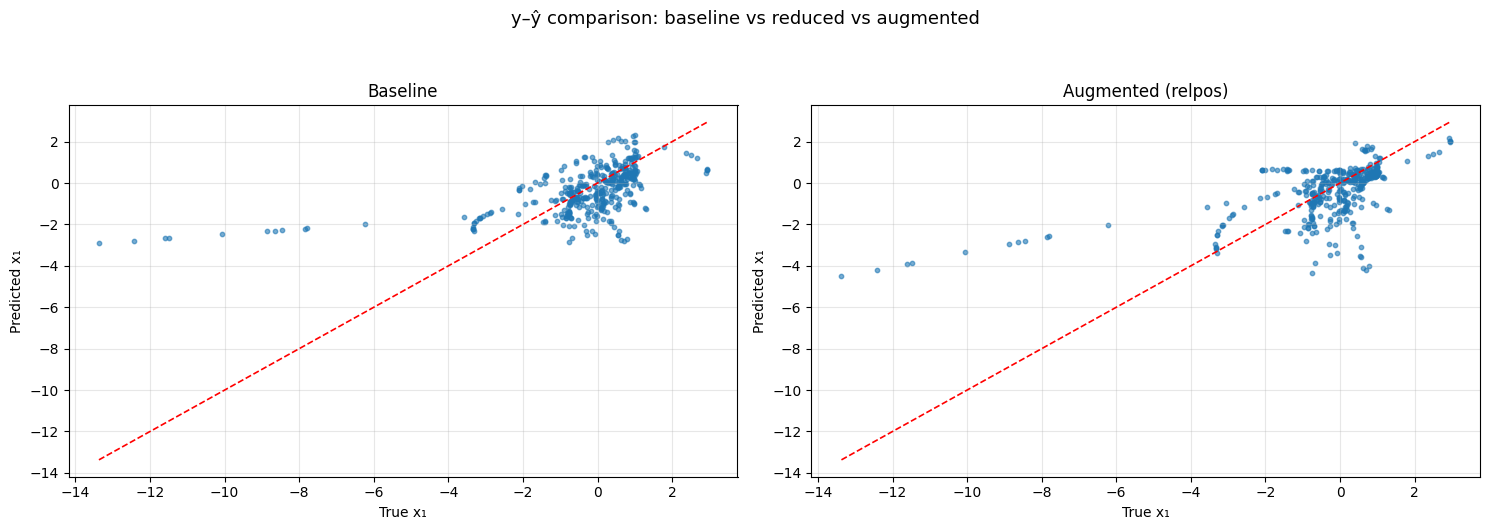

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Baseline model
model_base, rmse_base, degree_base = validate_poly_regression(
    X_train, y_train, X_val, y_val,
    degrees=range(1, 3), max_features=3000
)


# 3. Augmented model
X_train_aug = add_features(X_train_df, best_variant)
X_val_aug = add_features(X_val_df, best_variant)
model_aug, rmse_aug, degree_aug = validate_poly_regression(
    X_train_aug.values, y_train,
    X_val_aug.values, y_val,
    degrees=range(1, 3), max_features=3000
)

# 4. RMSE comparison
print("\n--- RMSE COMPARISON ---")
print(f"Baseline RMSE     = {rmse_base:.5f}")
print(f"Augmented RMSE ({best_variant}) = {rmse_aug:.5f}")

# 5. Visualization
def plot_y_yhat_compare(y_true, preds, labels):
    idx = np.random.choice(len(y_true), min(400, len(y_true)), replace=False)
    fig, axes = plt.subplots(1, len(preds), figsize=(15, 5))
    for ax, (y_pred, label) in zip(axes, zip(preds, labels)):
        ax.scatter(y_true[idx, 0], y_pred[idx, 0], s=10, alpha=0.6)
        ax.plot(
            [y_true[idx, 0].min(), y_true[idx, 0].max()],
            [y_true[idx, 0].min(), y_true[idx, 0].max()],
            'r--', lw=1.2
        )
        ax.set_title(label)
        ax.set_xlabel("True x₁")
        ax.set_ylabel("Predicted x₁")
        ax.grid(alpha=0.3)
    fig.suptitle("y–ŷ comparison: baseline vs reduced vs augmented", y=1.05, fontsize=13)
    plt.tight_layout()
    plt.show()

y_pred_base = model_base.predict(X_val)
y_pred_reduced = model_reduced.predict(X_val_reduced)
y_pred_aug = model_aug.predict(X_val_aug)

plot_y_yhat_compare(
    y_val,
    [y_pred_base, y_pred_aug],
    ["Baseline",  f"Augmented ({best_variant})"]
)


In [16]:
from joblib import dump
import pickle
from pathlib import Path

# Ensure results directory exists
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)

# Export model using joblib (better for sklearn models)
model_path = results_dir / 'model_aug.joblib'
dump(model_aug, model_path)

# Export DataFrame using pickle (preserves pandas DataFrame structure)
data_path = results_dir / 'X_val_aug.pkl'
with open(data_path, 'wb') as f:
    pickle.dump(X_val_aug, f)

print(f"Exported model to: {model_path}")
print(f"Exported validation data to: {data_path}")

Exported model to: results/model_aug.joblib
Exported validation data to: results/X_val_aug.pkl
